<a href="https://colab.research.google.com/github/WVF-1/Movie-Performance-Analytics/blob/main/Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Movie Performance Analytics — Notebook 1
## Data Cleaning & Feature Engineering

**Series:** May Newsletter — Movie Intelligence  
**Dataset:** TMDB Movies Metadata (~45k films)

This notebook handles all the messy work so Notebooks 2 and 3 can focus purely on analysis and storytelling.

### What we do here
1. Load and inspect `movies_metadata.csv`
2. Repair corrupt rows and coerce numeric columns
3. Parse the embedded JSON fields (`genres`, `production_companies`)
4. Engineer four core features: `profit`, `ROI`, `release_month`, `primary_genre`
5. Filter to the *analysis-ready* subset (both budget and revenue known)
6. Save a clean parquet for the downstream notebooks


## 0 · Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings("ignore")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)


pandas: 2.2.2
numpy: 2.0.2


## 1 · Load Raw Data

In [2]:
# movies_metadata has a handful of malformed rows (the id column sometimes
# contains a poster-path string).  low_memory=False suppresses dtype warnings.
df_raw = pd.read_csv("movies_metadata.csv", low_memory=False)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)


Shape: (45466, 24)
Columns: ['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [3]:
# Quick null audit
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
print("Null % per column:")
print(null_pct[null_pct > 0].round(1).to_string())


Null % per column:
belongs_to_collection    90.1
homepage                 82.9
tagline                  55.1
overview                  2.1
poster_path               0.8
runtime                   0.6
status                    0.2
release_date              0.2
imdb_id                   0.0
original_language         0.0
vote_average              0.0
vote_count                0.0
title                     0.0
video                     0.0
spoken_languages          0.0
revenue                   0.0
popularity                0.0
production_countries      0.0
production_companies      0.0


## 2 · Repair Numeric Columns

In [4]:
df = df_raw.copy()

# budget and revenue can contain garbage strings in corrupt rows — coerce to float
df["budget"]  = pd.to_numeric(df["budget"],  errors="coerce")
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")

# Replace explicit zeros with NaN — a $0 budget is a missing value, not a fact
df["budget"]  = df["budget"].replace(0, np.nan)
df["revenue"] = df["revenue"].replace(0, np.nan)

print(f"  budget  non-null: {df['budget'].notna().sum():,}")
print(f"  revenue non-null: {df['revenue'].notna().sum():,}")

# Vote fields
df["vote_average"] = pd.to_numeric(df["vote_average"], errors="coerce")
df["vote_count"]   = pd.to_numeric(df["vote_count"],   errors="coerce")
df["popularity"]   = pd.to_numeric(df["popularity"],   errors="coerce")
df["runtime"]      = pd.to_numeric(df["runtime"],      errors="coerce")


  budget  non-null: 8,890
  revenue non-null: 7,408


## 3 · Parse the `genres` Column

In [5]:
def parse_genre_list(raw):
    """Return a Python list of genre name strings from the stringified JSON."""
    try:
        items = ast.literal_eval(str(raw))
        return [g["name"] for g in items if isinstance(g, dict)]
    except Exception:
        return []

df["genre_list"]    = df["genres"].apply(parse_genre_list)
df["primary_genre"] = df["genre_list"].apply(lambda g: g[0] if g else "Unknown")
df["genre_count"]   = df["genre_list"].apply(len)

# Sanity check
print("Most common primary genres:")
print(df["primary_genre"].value_counts().head(10).to_string())


Most common primary genres:
primary_genre
Drama          11966
Comedy          8820
Action          4489
Documentary     3415
Horror          2619
Unknown         2442
Crime           1685
Thriller        1665
Adventure       1514
Romance         1191


## 4 · Parse `release_date`

In [6]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"]  = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month

MONTH_NAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
df["month_name"] = df["release_month"].map(MONTH_NAMES)

print("Year range:", df["release_year"].min(), "–", df["release_year"].max())
print("Releases per decade:")
df["decade"] = (df["release_year"] // 10 * 10).astype("Int64")
print(df["decade"].value_counts().sort_index().to_string())


Year range: 1874.0 – 2020.0
Releases per decade:
decade
1870        2
1880        4
1890       75
1900       87
1910      176
1920      432
1930     1317
1940     1494
1950     2080
1960     2622
1970     3472
1980     3931
1990     5677
2000    11207
2010    12799
2020        1


## 5 · Engineer Core Financial Features

In [7]:
# Only compute these where both values are present
df["profit"] = df["revenue"] - df["budget"]
df["ROI"]    = (df["revenue"] - df["budget"]) / df["budget"]

# Cap extreme ROI outliers at 99th percentile for visualisation stability
roi_99 = df["ROI"].quantile(0.99)
df["ROI_capped"] = df["ROI"].clip(upper=roi_99)

print(f"Profit range: ${df['profit'].min():,.0f}  →  ${df['profit'].max():,.0f}")
print(f"ROI range   : {df['ROI'].min():.2f}  →  {df['ROI'].max():.2f}  (capped at {roi_99:.2f})")


Profit range: $-165,710,090  →  $2,550,965,087
ROI range   : -1.00  →  12396382.00  (capped at 83.12)


## 6 · Budget Tier Labels

In [8]:
# Bucketing into production tiers — useful for groupby analysis in NB2
def budget_tier(b):
    if pd.isna(b):      return np.nan
    if b < 1e6:         return "Micro (<$1M)"
    if b < 1.5e7:       return "Low ($1M–$15M)"
    if b < 6e7:         return "Mid ($15M–$60M)"
    return              "Blockbuster (>$60M)"

df["budget_tier"] = df["budget"].apply(budget_tier)

TIER_ORDER = ["Micro (<$1M)", "Low ($1M–$15M)", "Mid ($15M–$60M)", "Blockbuster (>$60M)"]

print("Budget tier distribution:")
print(df["budget_tier"].value_counts().to_string())


Budget tier distribution:
budget_tier
Low ($1M–$15M)         3966
Mid ($15M–$60M)        2509
Micro (<$1M)           1485
Blockbuster (>$60M)     930


## 7 · Build the Analysis-Ready Dataset

In [9]:
# Require: both budget and revenue known, reasonable vote count (≥10),
# released as a proper movie (not a TV special / adult film)
mask = (
    df["budget"].notna() &
    df["revenue"].notna() &
    (df["vote_count"] >= 10) &
    (df["status"] == "Released") &
    (df["adult"] == "False")
)

df_clean = df[mask].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"Full dataset   : {len(df):,} rows")
print(f"Analysis-ready : {len(df_clean):,} rows  ({len(df_clean)/len(df)*100:.1f}% of total)")
print()
print("Columns retained:")
keep_cols = [
    "id","imdb_id","title","release_date","release_year","release_month","month_name",
    "decade","budget","revenue","profit","ROI","ROI_capped",
    "budget_tier","vote_average","vote_count","popularity","runtime",
    "primary_genre","genre_list","genre_count","original_language","production_countries"
]
df_clean = df_clean[keep_cols]
print(df_clean.columns.tolist())


Full dataset   : 45,466 rows
Analysis-ready : 5,128 rows  (11.3% of total)

Columns retained:
['id', 'imdb_id', 'title', 'release_date', 'release_year', 'release_month', 'month_name', 'decade', 'budget', 'revenue', 'profit', 'ROI', 'ROI_capped', 'budget_tier', 'vote_average', 'vote_count', 'popularity', 'runtime', 'primary_genre', 'genre_list', 'genre_count', 'original_language', 'production_countries']


In [10]:
df_clean.head(5)


,id,imdb_id,title,release_date,release_year,release_month,month_name,decade,budget,revenue,...,budget_tier,vote_average,vote_count,popularity,runtime,primary_genre,genre_list,genre_count,original_language,production_countries
0,862,tt0114709,Toy Story,1995-10-30,1995.0,10.0,Oct,1990,30000000.0,373554033.0,...,Mid ($15M–$60M),7.7,5415.0,21.946943,81.0,Animation,"[Animation, Comedy, Family]",3,en,"[{'iso_3166_1': 'US', 'name': 'United States o..."
1,8844,tt0113497,Jumanji,1995-12-15,1995.0,12.0,Dec,1990,65000000.0,262797249.0,...,Blockbuster (>$60M),6.9,2413.0,17.015539,104.0,Adventure,"[Adventure, Fantasy, Family]",3,en,"[{'iso_3166_1': 'US', 'name': 'United States o..."
2,31357,tt0114885,Waiting to Exhale,1995-12-22,1995.0,12.0,Dec,1990,16000000.0,81452156.0,...,Mid ($15M–$60M),6.1,34.0,3.859495,127.0,Comedy,"[Comedy, Drama, Romance]",3,en,"[{'iso_3166_1': 'US', 'name': 'United States o..."
3,949,tt0113277,Heat,1995-12-15,1995.0,12.0,Dec,1990,60000000.0,187436818.0,...,Blockbuster (>$60M),7.7,1886.0,17.924927,170.0,Action,"[Action, Crime, Drama, Thriller]",4,en,"[{'iso_3166_1': 'US', 'name': 'United States o..."
4,9091,tt0114576,Sudden Death,1995-12-22,1995.0,12.0,Dec,1990,35000000.0,64350171.0,...,Mid ($15M–$60M),5.5,174.0,5.231580,106.0,Action,"[Action, Adventure, Thriller]",3,en,"[{'iso_3166_1': 'US', 'name': 'United States o..."


In [11]:
print("Summary statistics for key financial columns:")
df_clean[["budget","revenue","profit","ROI"]].describe().applymap(lambda x: f"{x:,.0f}").T


Summary statistics for key financial columns:


,count,mean,std,min,25%,50%,75%,max
budget,"5,128","32,448,349","40,650,742",1,"6,000,000","18,000,000","40,000,000","380,000,000"
revenue,"5,128","94,583,058","169,031,641",1,"8,924,420","33,461,692","104,355,308","2,787,965,087"
profit,"5,128","62,134,709","142,283,011","-165,710,090","-1,377,896","13,241,198","66,956,533","2,550,965,087"
ROI,"5,128","5,302","218,794",-1,-0,1,3,"12,396,382"


## 8 · Quick Data Quality Plot

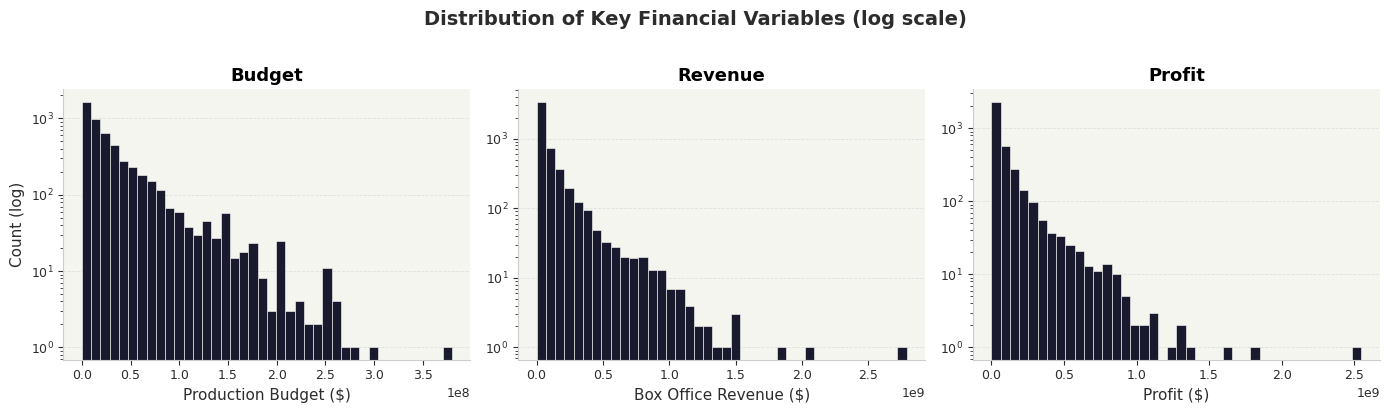

Saved: nb1_distributions.png


In [12]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Distribution of Key Financial Variables (log scale)", fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.02)

for ax, col, label in zip(axes,
        ["budget","revenue","profit"],
        ["Production Budget ($)", "Box Office Revenue ($)", "Profit ($)"]):
    data = df_clean[col].dropna()
    ax.hist(data[data > 0], bins=40, color=MIDNIGHT, edgecolor="white", linewidth=0.4, log=True)
    ax.set_xlabel(label)
    ax.set_ylabel("Count (log)" if col == "budget" else "")
    ax.set_title(col.title())
    style_spines(ax)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("nb1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb1_distributions.png")


## 9 · Save Cleaned Data

In [13]:
df_clean.to_parquet("movies_clean.parquet", index=False)
print(f"Saved movies_clean.parquet — {len(df_clean):,} rows × {df_clean.shape[1]} columns")
print()
print("You're ready for Notebook 2 ▶")


Saved movies_clean.parquet — 5,128 rows × 23 columns

You're ready for Notebook 2 ▶
